# __Group Assignment - Predicting Airbnb Listing Prices in Brisbane, Australia__

---

**Kaggle Competition Deadline:** Friday, 5 June 2026 at 3:00 PM (Week 13)  
**Assignment Due Date (iLearn):** Friday, 5 June 2026 at 11:59 PM (Week 13)  
**Total Marks:** 30  

**Overview**  
In this group assignment, you will form a team of three students and participate in a forecasting competition on Kaggle.

---
### General Instructions

- Each team member must create a Kaggle account and join the competition using the link:  
  https://www.kaggle.com/t/554f205a43a94920943d5227ae9dcbdb  

- Form a team of three students:  
  Choose a team leader who will create the team and invite the other members  
  The team name must begin with the unit code  

- All team members are expected to contribute to all tasks.  
  Each member must take primary responsibility for one of the three tasks.

- Your predictions must be generated using models developed in this assignment.  
  **A mark of zero will be awarded if your submitted forecasts cannot be reproduced from your code.**

- All results must be clearly presented and directly verifiable from your outputs and explanations.

- All written answers must be written in clear and complete sentences, supported by relevant tables, summary statistics, and visualisations where appropriate.  


<hr style="width:20%;margin-left:0;"> 

### Marks

- **Total Marks:** 30 (across 3 tasks)

- **Individual Mark Allocation:**  
  Each student’s mark is calculated as:   
  **0.5 × overall group assignment mark (%) + 0.5 × individual task mark (%)**,   
  with the combined percentage then converted to a mark out of 30.


<hr style="width:20%;margin-left:0;"> 

### Assignment Submission

1. **Kaggle Submission:**  
   - Submit your team’s forecasts on Kaggle to be ranked on the leaderboard  
2. **iLearn Submission (team leader only):**  
   - Submit the assignment as a Jupyter notebook, renamed to your **Kaggle team name**  
   - The notebook must include:
     - Names and student ID numbers of all team members  
     - Your Kaggle team name  
   - Submit **one 15-minute video presentation** of your work  
     - A penalty of **5 marks will be deducted per task** if a video presentation is not provided  

---
---

### <span style="background-color: yellow;">Fill out the following information

- Team Name on Kaggle: `BUSA3020 - ADT`
- Team Leader and Team Member 1: `Ngo Nguyet Tu Tran`
- Team Member 2: `Ngoc Anh Tran`
- Team Member 3: `Minh Dang Hoang`

---
---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  

**Total Marks: 10**

- Based on the Competition Overview, datasets, and additional information provided on Kaggle, along with insights gained from your own research (including relevant academic sources such as Google Scholar), answer the following questions.  
- Do not discuss any predictive models in this task.


---

Student in charge of this task: `Ngo Nguyet Tu Tran` (team member 1)

<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  
In approximately **300 words**, explain what we are trying to predict and how this problem can be applied in a real-world context.  
Discuss who may benefit from these predictions and how they might use them.


- **Purpose and problem statement**: This project aims to predict the nightly price of Airbnb listings in Brisbane, Australia, using a dataset of 3,735 training observations and 1,601 test observations. Each record represents a unique listing and contains a wide range of features, including location (e.g., neighbourhood, latitude, longitude), property characteristics (e.g., room type, number of bedrooms and bathrooms, accommodates), host attributes (e.g., superhost status, response rate), as well as customer reviews, ratings, availability, and revenue-related information. The target variable is the listing price, which reflects how much guests are charged per night.

- **Real-world application**: Predicting Airbnb prices is a real-world regression problem with strong practical relevance. Pricing in short-term rental markets is highly dynamic and influenced by multiple factors such as location desirability, property size, quality, and demand signals (e.g., reviews and availability). A predictive model can help estimate a “fair” or competitive price based on these characteristics, reducing uncertainty and improving decision-making. For example, instead of relying on intuition, hosts can use data-driven insights to set optimal prices that balance occupancy and revenue.

- **Stakeholder benefits**: Several stakeholders can benefit from these predictions. Airbnb hosts are the primary users, as they can use predicted prices to adjust their pricing strategies, remain competitive in their local market, and maximise revenue. Property investors and real estate agencies can use these insights to evaluate the profitability of potential properties and make informed investment decisions. Additionally, platforms like Airbnb, booking.com can leverage such models to provide automated pricing recommendations, improve user experience, and increase booking rates. Finally, marketers can use pricing insights to design targeted campaigns, positioning listings more effectively to attract specific customer segments.

Overall, accurate price prediction enables more efficient market functioning by aligning prices with underlying property value and demand conditions.

<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.

- **Evaluation metric**: The evaluation metric used in this competition is **Mean Absolute Percentage Error (MAPE)**, a widely used metric for assessing forecasting accuracy, particularly in business and economic contexts. MAPE measures the average magnitude of prediction errors as a percentage of the actual values, making it intuitive and easy to interpret.

- **MAPE Equation**:$$
\text{MAPE}
=
\frac{100}{n}
\sum_{i=1}^{n}
\left|
\frac{\text{actual}_i-\text{predicted}_i}
{\text{actual}_i}
\right|
$$

where:
- $n$ : sample size  
- $\text{actual}$ : the actual observed value  
- $\text{forecast}$ : the predicted (forecasted) value  

- **Advantages**: One key advantage of MAPE is its **interpretability**. Because errors are expressed as percentages, stakeholders can easily understand model performance (e.g., “on average, predictions are off by 10%”). This also allows for **straightforward comparison across different models or datasets**, even when price scales vary. Additionally, MAPE **treats all errors proportionally**, making it useful in contexts like Airbnb pricing where relative error (rather than absolute error) is often more meaningful.

- **Limitations**: However, MAPE also has several limitations. First, it is **undefined when actual values are zero**, since division by zero is impossible. While this may be less common in pricing data, it can still pose issues in some datasets. Second, MAPE tends to **penalise errors asymmetrically**, placing heavier penalties on underestimation than overestimation when actual values are small. Third, it can be **sensitive to very small actual values**, where even minor prediction errors result in extremely large percentage errors, potentially distorting overall performance. Finally, MAPE does not differentiate between the importance of different observations, treating all errors equally regardless of business impact.

Overall, while MAPE is simple and intuitive, its limitations should be carefully considered when interpreting model performance.


<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [37]:
import pandas as pd
import numpy as np

# Import train set and test set
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")
print(train.shape,test.shape)
train.head(5) #Display 5 first rows of train set

(3735, 65) (1601, 64)


,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,...,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,price
0,0,city scrape,The Nestt,Enjoy a memorable visit when you stay in this ...,NaN,38029254,Mark,2015-07-09,NaN,NaN,...,4.61,4.28,4.50,f,8,8,0,0,0.58,$97.00
1,1,city scrape,Bayside Bliss - By the Water & Near the Airport,"Relax by the water and close to the airport, B...",Wynnum is nestled along Brisbane's sunny south...,33488214,Claire,2015-05-16,"Wynnum, Australia",NaN,...,4.94,4.88,4.69,f,1,1,0,0,0.93,$205.00
2,2,city scrape,Cozy 1 Bedroom Apartment with Infinity Pool,My stunning apartment is located in one of the...,Staying here allows you to experience the neve...,401146490,Hao,2021-05-11,NaN,"Roger and I love traveling, we fell in love wi...",...,4.81,4.67,4.56,t,7,7,0,0,1.33,$186.00
3,3,city scrape,City Stay-Executive 1.5 Bedroom,Experience modern urban living in our stylish ...,NaN,83183834,John,2016-07-11,"Hamilton, Australia",NaN,...,NaN,NaN,NaN,f,1,1,0,0,NaN,$157.00
4,4,city scrape,Private Oasis! 3Bed/2Bath/1Car ~ 5mins to CBD,Brisbane inner-city living at its best! <br />...,Location (walking)<br /><br />•\t1 min e-Scoot...,3384506,Andy,2012-08-27,"Brisbane, Australia",Brisbane’s Leading Property Management Company...,...,4.87,4.83,4.57,f,132,132,0,0,3.18,$300.00


In [38]:
test.head(5) #Display 5 first rows of test set

,ID,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3735,city scrape,The perfect inner city location FREE parking,Enjoy a stylish experience at this centrally l...,NaN,35524154,Luke,2015-06-11,"Brisbane, Australia",NaN,...,4.86,4.81,4.94,4.76,f,1,1,0,0,3.34
1,3736,city scrape,Chi11 on the Hill - Cave 2,"In Spring Hill, and walking distance from the ...",NaN,21820096,David,2014-09-26,"Petrie Terrace, Australia",David here. Architect with wife and two kids.,...,NaN,NaN,NaN,NaN,f,7,0,7,0,NaN
2,3737,city scrape,Kooii Apartments 1 Bedroom Urban View,We offer a fresh and new exclusive collection ...,"Set in the heart of Fortitude Valley, one of B...",508442405,Kooii,2023-04-03,NaN,NaN,...,4.75,4.45,4.85,4.60,t,5,5,0,0,0.64
3,3738,city scrape,Stunning Renovated Heritage 1 Bed Apart 4- 3km...,Welcome!!<br /><br />Beautiful renovated self-...,Location! Location!..... Auchenflower is a ver...,49128857,Laetitia,2015-11-15,"Brisbane City, Australia",My passion is travelling! I love to travel bo...,...,NaN,NaN,NaN,NaN,f,5,5,0,0,NaN
4,3739,city scrape,Panoramic views of the CBD skyline -1BR1BR unit,Nestled in the vibrant and highly sought-after...,NaN,490286067,Fangzhou,2022-12-05,NaN,We are a dedicated property management team se...,...,4.42,4.88,4.88,4.61,f,11,11,0,0,3.68


In [39]:
#Train set overview
display(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 65 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ID                                            3735 non-null   int64  
 1   source                                        3735 non-null   object 
 2   name                                          3735 non-null   object 
 3   description                                   3697 non-null   object 
 4   neighborhood_overview                         1754 non-null   object 
 5   host_id                                       3735 non-null   int64  
 6   host_name                                     3733 non-null   object 
 7   host_since                                    3733 non-null   object 
 8   host_location                                 2917 non-null   object 
 9   host_about                                    2243 non-null   o

None

In [40]:
#Test set overview
display(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 64 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   ID                                            1601 non-null   int64  
 1   source                                        1601 non-null   object 
 2   name                                          1601 non-null   object 
 3   description                                   1577 non-null   object 
 4   neighborhood_overview                         754 non-null    object 
 5   host_id                                       1601 non-null   int64  
 6   host_name                                     1601 non-null   object 
 7   host_since                                    1601 non-null   object 
 8   host_location                                 1264 non-null   object 
 9   host_about                                    983 non-null    o

None

In [41]:
# Report missing values in train set
missing_train = pd.DataFrame({
    'Missing_count_train': train.isnull().sum(),
    'Missing_percent_train': ((train.isnull().sum()/len(train))*100).round(2)
})
#Only display variables containing missing values
missing_train = missing_train[missing_train['Missing_count_train'] > 0] \
                                .sort_values(by='Missing_count_train', ascending=False)

# Report missing values in test set
missing_test = pd.DataFrame({
    'Missing_count_test': test.isnull().sum(),
    'Missing_percent_test': ((test.isnull().sum() / len(test)) * 100).round(2)
})
#Only display variables containing missing values
missing_test = missing_test[missing_test['Missing_count_test'] > 0] \
                              .sort_values(by='Missing_count_test', ascending=False)

#Display the report
print("Missing values in train set")
display(missing_train)
print("Missing values in test set")
display(missing_test)

Missing values in train set


,Missing_count_train,Missing_percent_train
host_neighbourhood,3599,96.36
neighborhood_overview,1981,53.04
host_about,1492,39.95
host_location,818,21.90
reviews_per_month,437,11.70
review_scores_rating,437,11.70
review_scores_accuracy,437,11.70
review_scores_cleanliness,437,11.70
review_scores_checkin,437,11.70
review_scores_communication,437,11.70


Missing values in test set


,Missing_count_test,Missing_percent_test
host_neighbourhood,1536,95.94
neighborhood_overview,847,52.90
host_about,618,38.60
host_location,337,21.05
reviews_per_month,183,11.43
review_scores_communication,183,11.43
last_review,183,11.43
first_review,183,11.43
review_scores_cleanliness,183,11.43
review_scores_checkin,183,11.43


In [42]:
print("Missing train:", missing_train.shape)
print("Missing test:", missing_test.shape)

Missing train: (33, 2)
Missing test: (25, 2)


In general, both the training and test datasets contain a substantial presence of missing values, with similar patterns observed across variables.

**Training set**

In the training dataset (3,735 observations), there are 33 variables containing missing values. The highest proportions of missing data are found in text-based host and neighbourhood features, including `host_neighbourhood` (96.36%), `neighborhood_overview` (53.04%), `host_about` (39.95%), and `host_location` (21.90%). These variables are largely descriptive and optional, which explains their high missing rates.

A consistent pattern is observed in review-related variables (e.g., `review_scores_rating`, `reviews_per_month`, `first_review`, `last_review`), each with approximately 11.7% missing values. This is likely because some listings have not yet received any reviews, indicating that the missingness is meaningful rather than random. Additionally, several host-related features such as `host_response_rate` (7.68%) and `host_acceptance_rate` (5.38%) show moderate levels of missing data, suggesting incomplete host profiles.

**Testing set**

In the test dataset (1,601 observations), 25 variables contain missing values. The same variables like `host_neighbourhood`, `neighborhood_overview`, `host_about`, and `host_location`, show the highest missing percentages (ranging from ~21% to ~96%). Review-related features consistently have around 11.43% missing values, reinforcing the assumption that missingness is linked to the absence of customer reviews rather than data quality issues.

In addition, several variables in the training dataset exhibit minimal missing values, particularly `host_name`, `host_listings_count`, and host verification-related features (e.g., `host_identity_verified`, `host_has_profile_pic`, and `host_verifications`). These variables have negligible missing rates (close to 0%), indicating that core host profile information is generally well-populated. In contrast, these variables do not contain missing values in the test dataset, suggesting a higher level of data completeness for host-related attributes. This consistency implies that such features are reliably recorded and may serve as stable predictors in the modelling process.

Overall, the missing data patterns are consistent between training and test datasets, which is important for model generalisation. Importantly, many missing values are not random but reflect real-world conditions (e.g., new listings without reviews or incomplete host information). Therefore, these variables should be handled carefully through appropriate imputation or feature engineering, rather than being removed entirely.

<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

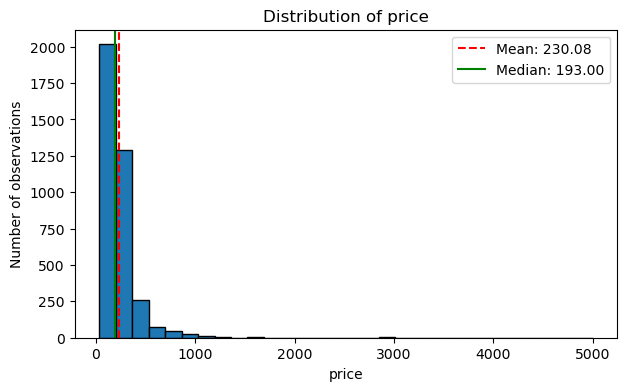

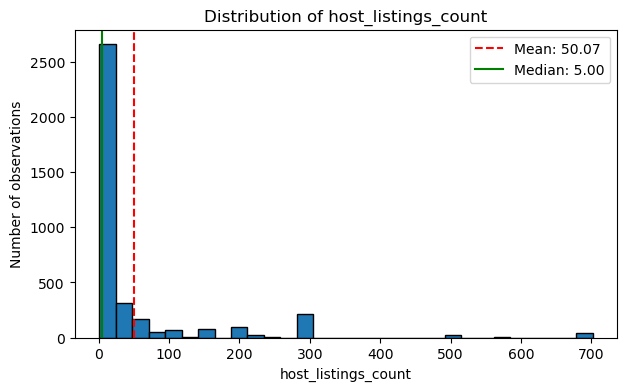

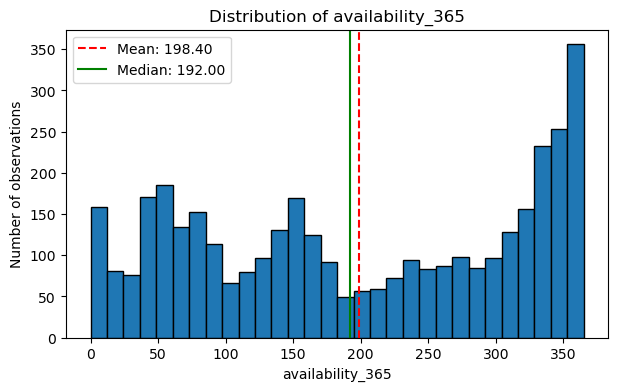

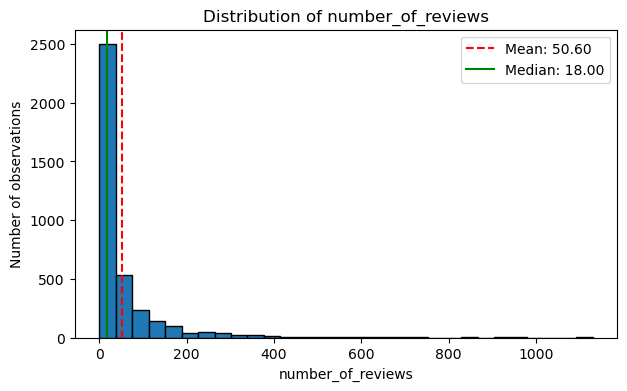

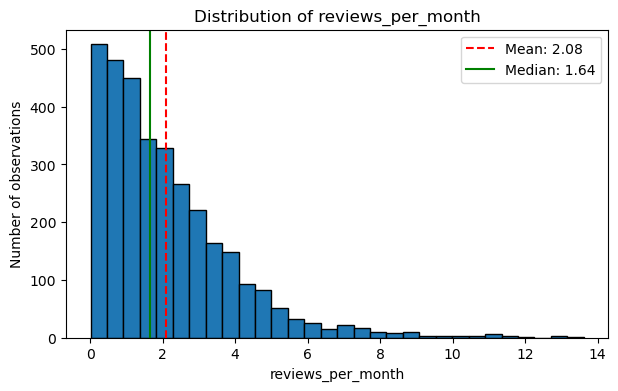

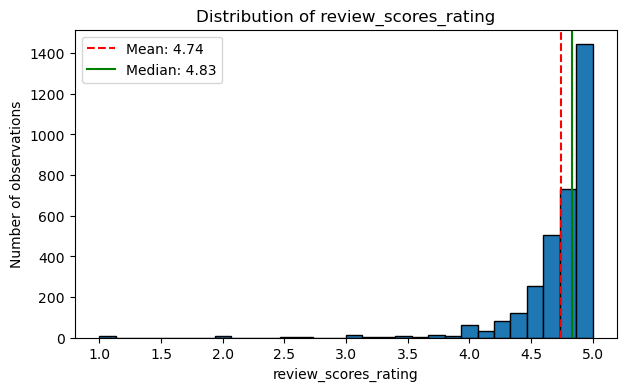

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# convert price from string to numeric
train['price'] = train['price'].replace('[\$,]', '', regex=True).astype(float)

#selection of numeric variables and plots
#histograms for key numerical features
hist_cols = ['price', 'host_listings_count','availability_365','number_of_reviews','reviews_per_month','review_scores_rating']

for col in hist_cols:
    plt.figure(figsize=(7,4))
    
    data = train[col].dropna() #drop missing values
    
    # histogram
    plt.hist(data, bins=30, edgecolor = 'black')
    
    # mean & median
    mean_val = data.mean()
    median_val = data.median()
    
    plt.axvline(mean_val, linestyle='--', c='r', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, linestyle='-', c='g', label=f'Median: {median_val:.2f}')
    
    # title & labels
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of observations')
    plt.legend()
    
    plt.show()

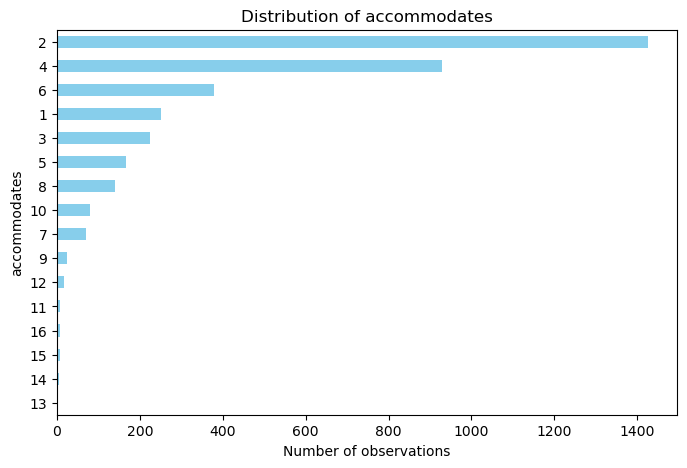

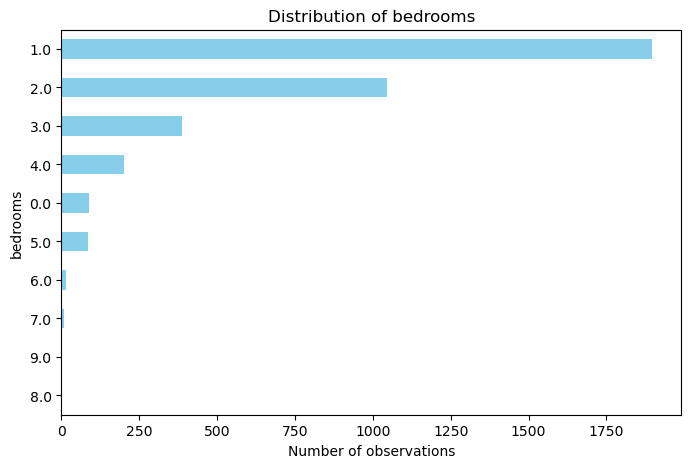

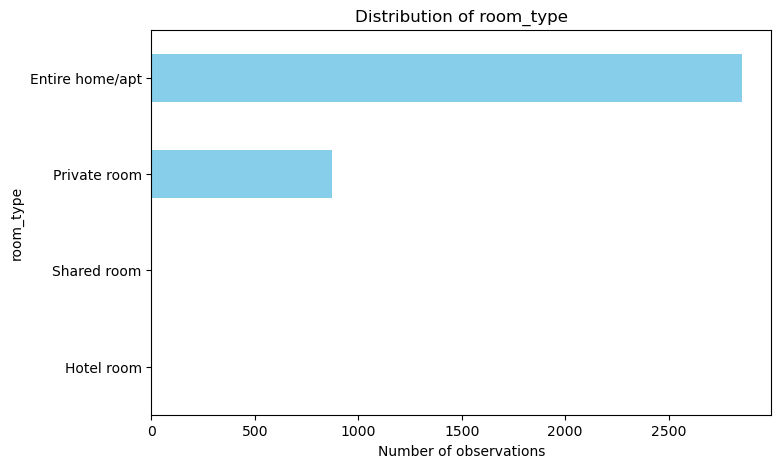

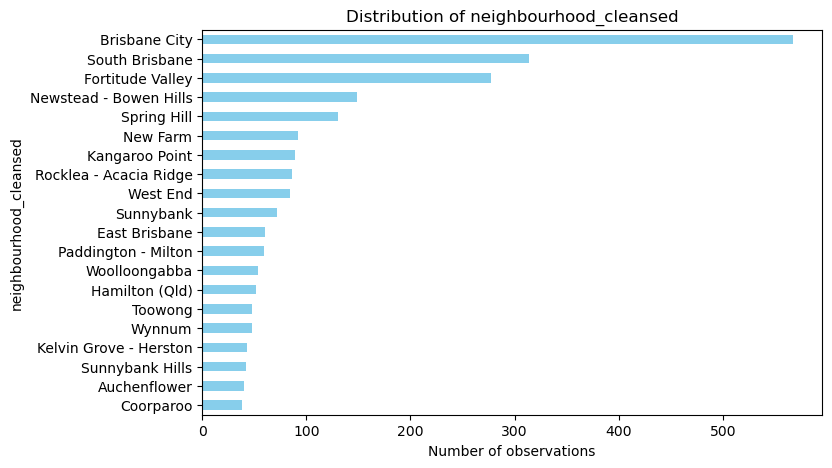

In [44]:
#selection of discrete features (bedrooms, accomodates) and categorical variables
#using bar charts
bar_cols = ['accommodates','bedrooms','room_type','neighbourhood_cleansed']

for col in bar_cols:
    plt.figure(figsize=(8,5))

    data = train[col].value_counts()
    
    if col in ['neighbourhood_cleansed']:
        data = data.head(20)
    
    data.sort_values().plot(kind='barh',color='skyblue')
    
    plt.title(f'Distribution of {col}')
    plt.xlabel('Number of observations')
    plt.ylabel(col)
    
    plt.show()

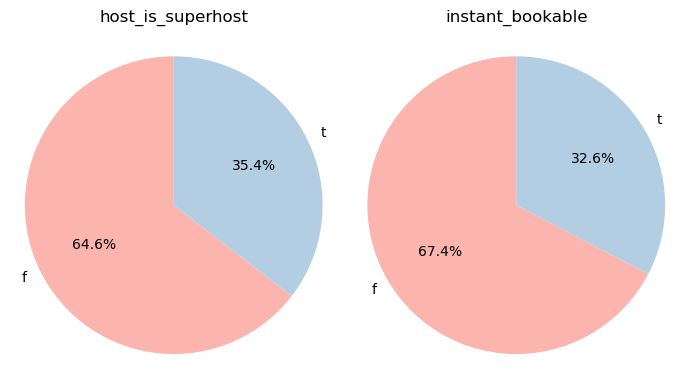

In [45]:
#pie charts for categorical variables
pie_cols = ['host_is_superhost', 'instant_bookable']

fig, axes = plt.subplots(1, 2, figsize=(7,4))  # 1 row, 2 columns

for i, col in enumerate(pie_cols):
    data = train[col].value_counts()
    
    axes[i].pie(
        data,
        labels=data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Pastel1.colors[:len(data)]
    )
    
    axes[i].set_title(f'{col}')
    axes[i].axis('equal')

plt.tight_layout()
plt.show()

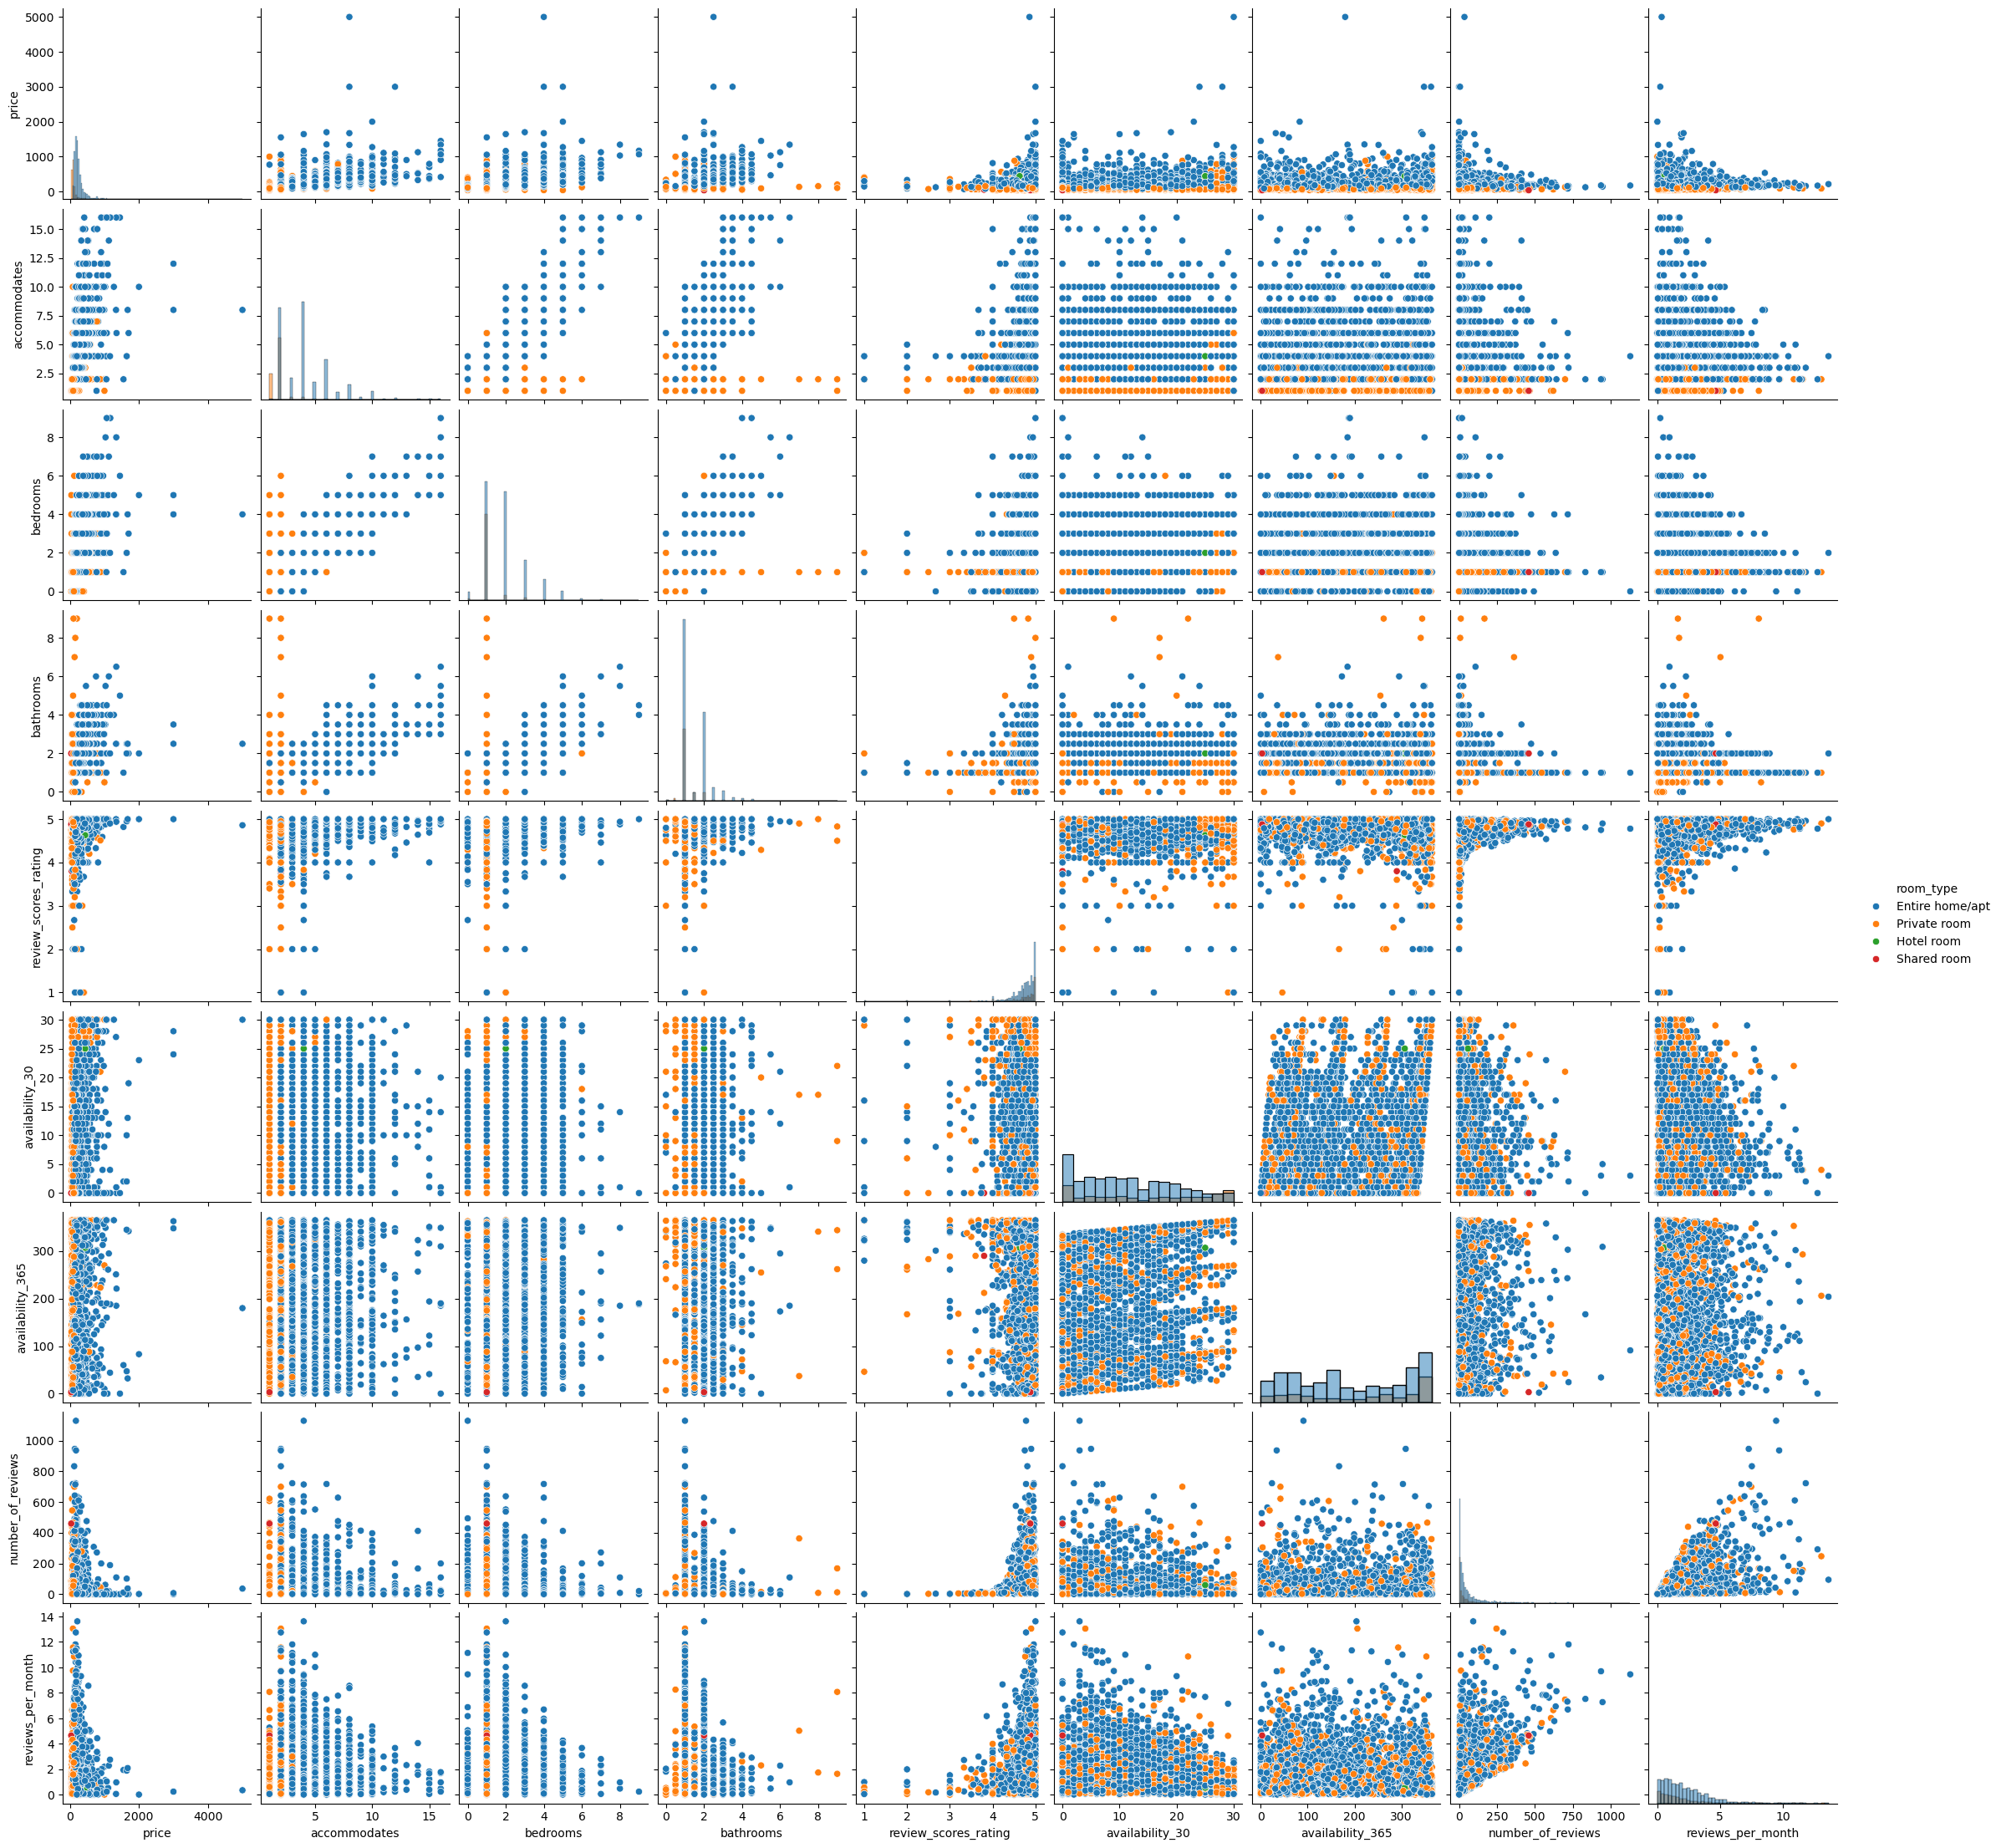

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# select key features
key_features = [
    'price',                   
    'accommodates',            
    'bedrooms',                 
    'bathrooms',               
    'review_scores_rating',
    'availability_30',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'room_type'
]

# pairplot
sns.pairplot(
    train[key_features],
    hue='room_type',      
    diag_kind='hist'
)

plt.show()

**Histograms** 

- The distributions of `price` and `host_listings_count` are **both highly right-skewed**, indicating that most listings are concentrated at lower values, with a small number of extreme high values. The majority of listing prices are below `$1,000`, with an average price of approximately `$230`. Similarly, most hosts manage a relatively small number of properties, with a median of around 5 listings, although a few hosts own significantly larger listings (e.g., over 200), which appear as outliers.

- The variable `availability_365` does **not follow a normal distribution** and shows a wide spread across the full range of days. This suggests complex booking patterns, where some listings are rarely available (possibly due to high demand), while others remain available for most of the year.

- The distributions of `number_of_reviews` and `reviews_per_month` are **both highly right-skewed**, indicating that most listings receive relatively few reviews, while a small number of listings accumulate a large volume of reviews. On average, listings have approximately 50 total reviews, with around 2 reviews per month. The variable reviews_per_month can be interpreted as a proxy for demand, as higher values suggest greater booking frequency and listing popularity.

- In terms of ratings, the distribution of `review_scores_rating` is heavily **concentrated at high values**, with most listings receiving ratings above 4.5 and an average rating of approximately 4.8. This indicates generally high customer satisfaction across listings. However, a small number of outliers with low ratings (around 1–2) are present, suggesting that poorly performing listings are relatively rare.


**Bar charts** 
- Bar charts were used for discrete variables such as `accommodates` and `bedrooms` and some categorical features.

- For `accommodates`, the majority of listings are designed for 2 guests, indicating a strong focus on couples or small groups. There is also a substantial number of listings accommodating 3 to 6 guests, while properties hosting more than 10 guests are relatively rare.

- A similar pattern is observed for `bedrooms`, where 1–2 bedroom listings dominate the market, and larger properties (3+ bedrooms) are less common. Observed in `room_type`, these properties are more likely to be entire homes or apartments, whereas shared rooms and hotel room listings are rare overall.

- Based on distribution of `neighborhood_cleansed`, listings are concentrated in key areas such as the City, South Brisbane, Fortitude Valley, and surrounding hills, highlighting these as major locations of Airbnb activity.

**Pie charts**
- Interestingly, the proportions of `host_is_superhost` and `instant_bookable` are relatively similar. Approximately 35.4% of listings are hosted by superhosts, while 32.6% of listings offer instant booking, suggesting a moderate level of service quality and convenience across the platform.

**Pair plots**
- The pairplot indicates weak-to-moderate relationships between individual predictors and price, with substantial dispersion observed across most variables. Property characteristics such as `accommodates`, `bedrooms`, and `bathrooms` show the clearer positive associations with price.
- This suggests that Airbnb pricing is influenced by multiple interacting factors rather than a single dominant predictor.

<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



In [47]:
#Create feature lists for 5 types of variables
numeric_cols = [
    'price',
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'host_listings_count',
    'latitude',
    'longitude',
    'availability_365',
    'availability_30',
    'estimated_revenue_l365d',
    'minimum_nights',
    'maximum_nights',
    'maximum_nights_avg_ntm',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'review_scores_location',
    'review_scores_cleanliness']

ordinal_cols = ['host_response_time']

nominal_cols = [
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'host_identity_verified',
    'instant_bookable',
    'amenities']

temporal_cols = [
    'host_since',
    'first_review',
    'last_review']

percentage_cols =['host_response_rate',
    'host_acceptance_rate']

#Print types of variables and its length
print(f"Numerical variables: {len(numeric_cols)}",[numeric_cols])
print(f"Ordinal variables: {len(ordinal_cols)}",[ordinal_cols])
print(f"Nominal variables: {len(nominal_cols)}",[nominal_cols])
print(f"Temporal/Date variables: {len(temporal_cols)}",[temporal_cols])
print(f"Percentage variables: {len(percentage_cols)}",[percentage_cols])

Numerical variables: 19 [['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms', 'host_listings_count', 'latitude', 'longitude', 'availability_365', 'availability_30', 'estimated_revenue_l365d', 'minimum_nights', 'maximum_nights', 'maximum_nights_avg_ntm', 'number_of_reviews', 'review_scores_rating', 'reviews_per_month', 'review_scores_location', 'review_scores_cleanliness']]
Ordinal variables: 1 [['host_response_time']]
Nominal variables: 7 [['room_type', 'property_type', 'neighbourhood_cleansed', 'host_is_superhost', 'host_identity_verified', 'instant_bookable', 'amenities']]
Temporal/Date variables: 3 [['host_since', 'first_review', 'last_review']]
Percentage variables: 2 [['host_response_rate', 'host_acceptance_rate']]


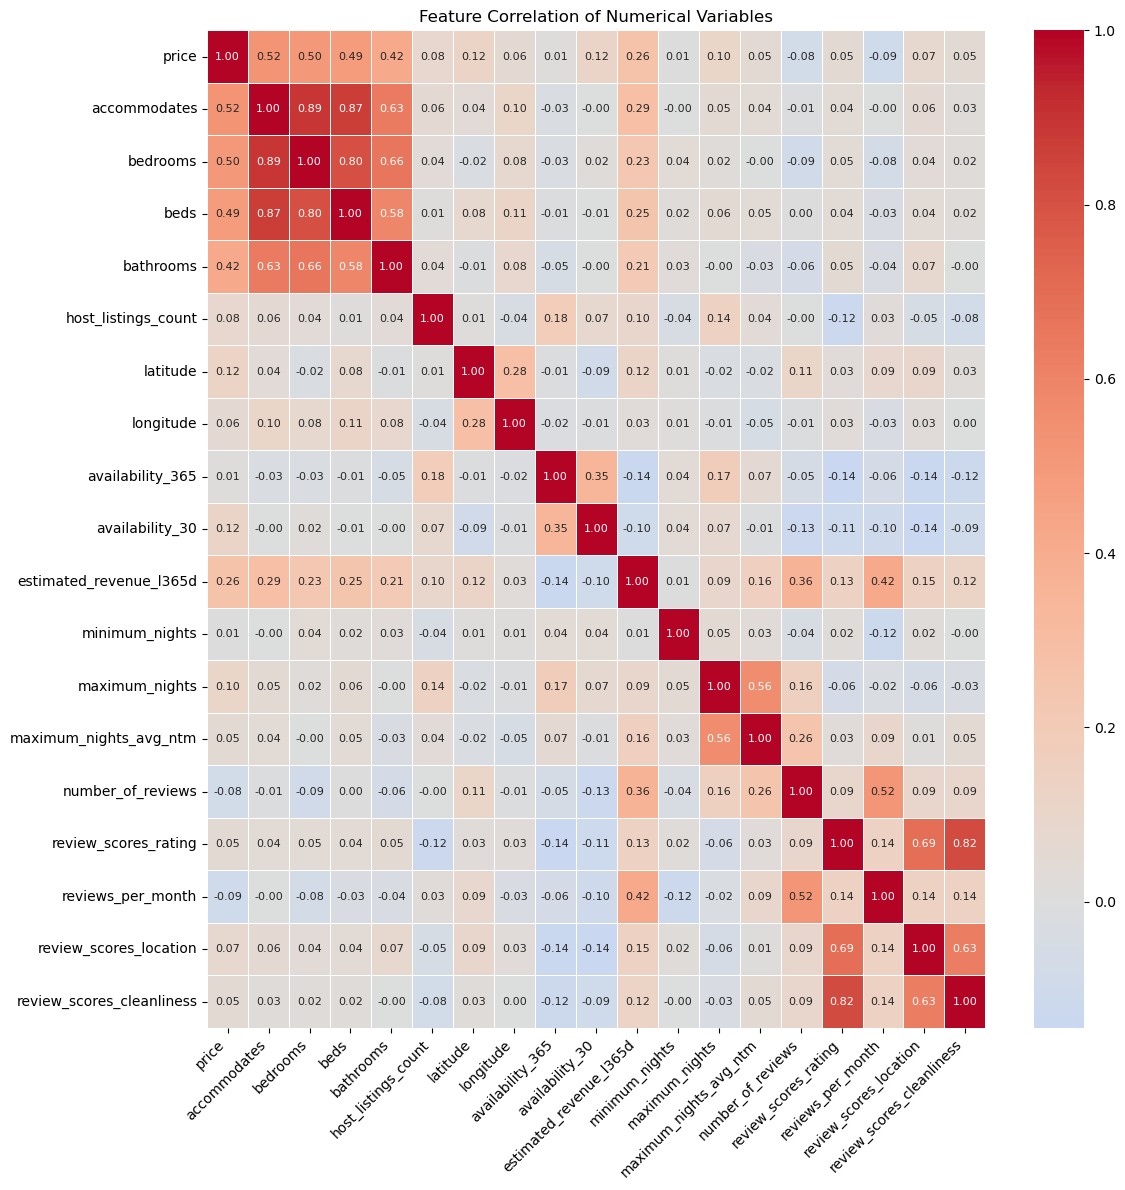

In [48]:
#Feature correlation for numerical variables
import seaborn as sns
import matplotlib.pyplot as plt

corr = train[numeric_cols].corr()

plt.figure(figsize=(12,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',     
    center=0,            #adjust the color when value is 0
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Feature Correlation of Numerical Variables")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

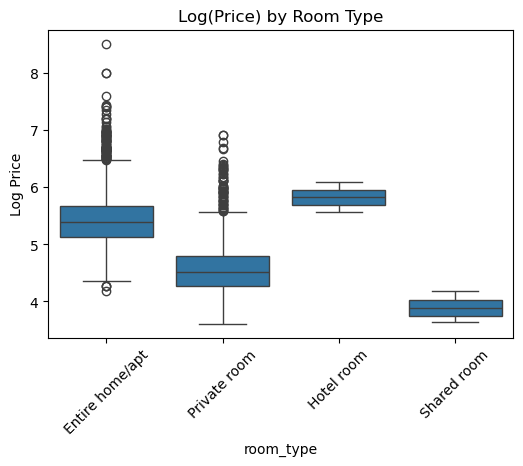

In [49]:
#using boxplot for room type vs price
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.boxplot(
    x='room_type',
    y=np.log1p(train['price']),       #using log for price because of its skewness
    data=train
)

plt.title('Log(Price) by Room Type')
plt.ylabel('Log Price')
plt.xticks(rotation=45)

plt.show()

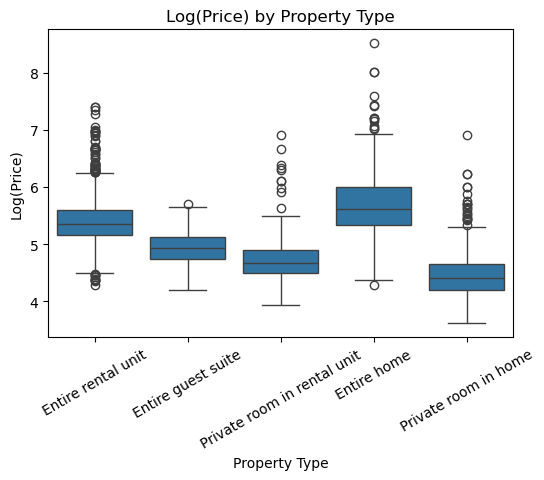

In [50]:
#boxplot for top 5 property types
import seaborn as sns
import matplotlib.pyplot as plt

top_property = train['property_type'].value_counts().head(5).index

plot_data = train[train['property_type'].isin(top_property)]

plt.figure(figsize=(6,4))

sns.boxplot(
    data=plot_data,
    x='property_type',
    y=np.log1p(plot_data['price'])
)

plt.title('Log(Price) by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Log(Price)')
plt.xticks(rotation=30)

plt.show()

In [51]:
#Statistic summary for numerical variables
pd.set_option('display.float_format', '{:.2f}'.format)
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,3735.00,230.08,194.65,36.00,129.00,193.00,267.00,5000.00
accommodates,3735.00,3.70,2.31,1.00,2.00,3.00,4.00,16.00
bedrooms,3733.00,1.76,1.11,0.00,1.00,1.00,2.00,9.00
beds,3732.00,2.12,1.58,0.00,1.00,2.00,3.00,24.00
bathrooms,3730.00,1.42,0.71,0.00,1.00,1.00,2.00,9.00
host_listings_count,3733.00,50.07,111.88,1.00,1.00,5.00,32.00,702.00
latitude,3735.00,-27.48,0.06,-27.66,-27.49,-27.47,-27.46,-27.07
longitude,3735.00,153.03,0.05,152.74,153.02,153.03,153.05,153.42
availability_365,3735.00,198.40,119.51,0.00,83.00,192.00,322.00,365.00
availability_30,3735.00,12.07,9.03,0.00,4.00,11.00,19.00,30.00


In [52]:
#Summary of top 20 neighbourhood_cleansed
top_neigh = train['neighbourhood_cleansed'].value_counts().head(20).index

train[train['neighbourhood_cleansed'].isin(top_neigh)] \
    .groupby('neighbourhood_cleansed')['price'] \
    .agg(['mean','median','count']) \
    .sort_values(by='mean', ascending=False)

,mean,median,count
neighbourhood_cleansed,,,
New Farm,281.21,224.50,92
Brisbane City,275.31,238.00,567
Newstead - Bowen Hills,270.84,207.00,149
Hamilton (Qld),265.77,207.50,52
Woolloongabba,248.67,189.00,54
Rocklea - Acacia Ridge,241.10,230.00,86
Paddington - Milton,241.05,207.00,59
Kangaroo Point,235.96,199.00,89
Spring Hill,233.02,180.50,130


In [53]:
#Statistical table for host response time (categorical feature)
train.groupby('host_response_time')['price'].agg(
    ['mean', 'median', 'count']
).sort_values('median', ascending=False)

,mean,median,count
host_response_time,,,
within a day,248.40,203.00,181
within an hour,225.49,194.00,2879
within a few hours,222.01,180.00,320
a few days or more,326.31,140.50,68


In [54]:
train.groupby('instant_bookable')['price'].agg(['mean','median','count']) #statistical summary of instant_bookable

,mean,median,count
instant_bookable,,,
f,227.33,185.00,2516
t,235.75,201.00,1219


**Variable classification**
- The final feature set consisted of 32 variables, including 19 numerical, 1 ordinal, 7 nominal, 3 temporal, and 2 percentage-based variables.
  
| Feature Name | Variable Type | Discription and Justification |
|----------|----------|----------|
| price | Numeric | Target variable|
| accommodates | Numeric | Maximum number of guests the property can host. Included because larger capacities are associated with higher prices. |
| bedrooms | Numeric | Number of bedrooms in the property. Reflects property size and showed a positive relationship with price |
| beds | Numeric | Number of available beds. Provides additional information about accommodation capacity and property value. |
| bathrooms | Numeric | Number of bathrooms in the property. Larger and better-equipped properties tend to command higher prices |
| host_listings_count | Numeric | Number of listings managed by the host. Captures differences between casual and professional hosts |
| latitude | Numeric | Geographic location of the listing. Included to capture spatial variation in Airbnb prices |
| longitude | Numeric | Geographic location of the listing. Complements latitude in representing location effects |
| availability_365 | Numeric | Number of available days per year. May reflect demand patterns and pricing strategies |
| availability_30 | Numeric | Number of available days in the next 30 days. Captures short-term availability and demand conditions |
| estimated_revenue_l365d | Numeric | Estimated annual revenue of the listing. Presents moderate positive correlation with price |
| minimum_nights | Numeric | Minimum stay requirement. May influence pricing through booking restrictions |
| maximum_nights | Numeric | Maximum allowed stay length. Captures host booking preferences and rental strategy |
| maximum_nights_avg_ntm | Numeric | Average future maximum stay requirement. Provides additional information on listing policies |
| number_of_reviews | Numeric | Total number of reviews received. Acts as a proxy for popularity and booking activity |
| review_scores_rating | Numeric | Overall guest rating score. Reflects listing quality and customer satisfaction |
| reviews_per_month | Numeric | Reviews received per month. Serves as a proxy for demand and occupancy |
| review_scores_location | Numeric | Guest rating of location. Captures perceived attractiveness of the area |
| review_scores_cleanliness | Numeric | Guest rating of cleanliness. Reflects service quality and guest experience |
| host_response_time | Ordinal | Typical host response speed. Indicates host responsiveness and service quality |
| room_type | Nominal | Type of accommodation offered. EDA showed clear price differences across room types |
| property_type | Nominal | Property category (e.g., apartment, house). Captures structural differences between listings |
| neighbourhood_cleansed | Nominal | Neighbourhood where the listing is located. Included due to substantial price variation across areas |
| host_is_superhost | Nominal | Indicates whether the host is a superhost. May capture host reputation and reliability |
| host_identity_verified | Nominal | Indicates whether the host's identity is verified. Reflects trust and credibility |
| instant_bookable | Nominal | Indicates whether guests can book instantly. May affect convenience and pricing |
| amenities | Nominal| List of amenities provided. Represents the level of facilities available to guests |
| host_since | Temporal | Date the host joined Airbnb. Used to derive host experience and hosting tenure |
| first_review | Temporal | Date of first review. Provides information about listing age and market presence |
| last_review | Temporal | Date of most recent review. Captures recent activity and engagement |
| host_response_rate | Percent | Percentage of inquiries answered by the host. Measures responsiveness and service quality |
| host_acceptance_rate | Percent | Percentage of booking requests accepted. Reflects host booking behaviour and availability |

**Feature analysis**

*Feature correlation*

- The correlation matrix indicates that property-related features, including `accommodates`, `bedrooms`, `beds`, and `bathrooms`, exhibit the **strongest positive relationships with price**, with correlation coefficients ranging approximately from 0.4 to 0.5. This suggests that larger properties, which can accommodate more guests and offer more rooms, tend to command higher prices. Besides, `estimated_revenue_l365d` shows a moderate postive correlation with price, capturing market performance and earning potential.

- Following the property-related features, `latitude` and availability-related variables (e.g., `availability_30` and `maximum_nights`) show **moderate correlations with price**, with coefficients above 0.10, indicating a modest relationship. This is followed by variables such as `review_scores_rating`, `longitude`, and `host_listings_count`, which exhibit weaker relationships with price, generally ranging between 0.05 and 0.08.

- The remaining numerical variables show **very low correlations** (below 0.01), suggesting minimal linear relationships with price when considered individually.

*Boxplot*

- The boxplot analysis further highlights **the importance of room type**. Hotel rooms have the highest median prices, followed by entire homes/apartments, while private rooms and shared rooms are significantly cheaper. Additionally, entire homes and private rooms display a wider spread with numerous outliers, reflecting substantial variability in pricing within these categories. The clear separation in medians and distributions across room types indicates that property type is a strong driver of price.

- Clear differences in price distributions across `property_type` are captured in the boxplot of top 5 property types. Entire homes have the highest median prices, followed by entire rental units, while private-room accommodations are considerably cheaper. This suggests that the `property_type` has a strong influence on Airbnb pricing

*Statistical tables for numerical variables*
- Larger properties (more accommodates, bedrooms, and bathrooms) tend to be associated with higher prices.
- Host listing count may capture differences between casual and professional hosts, potentially influencing pricing strategies.
- Review scores provide information about listing quality, although their relationship with price appears weaker.
- Availability and review activity variables may reflect demand patterns and contribute to price variation.
- The substantial variability observed across numerical features suggests potential predictive value for modelling Airbnb prices.

*Statistical tables for categorical variables*
- Analysis of `neighbourhood_cleansed` shows that locations with higher-ranked neighbourhoods have **relatively higher mean and median prices** (generally above `$200`), whereas lower-ranked neighbourhoods exhibit lower pricing levels (mean below `$180` and median below `$150`). This suggests that location plays an important role in determining price, likely due to differences in demand, accessibility, and local amenities.

- Regarding `host_response_time`, listings with slower response times generally exhibit lower median prices. This suggests that host responsiveness may be associated with listing quality and guest experience, although some categories contain relatively few observations.

- In contrast, **instant booking availability demonstrates a modest relationship with price**. Listings that allow instant booking have higher median prices (`$201`) compared to those that do not (`$185`), suggesting that convenience and ease of booking may allow hosts to charge a premium. However, the difference remains relatively small, indicating a moderate effect to price.

**Justification of feature selection**

- The selected features are justified **based on their observed relationships with price in the exploratory analysis**. Property-related variables such as `accommodates`, `bedrooms`, and `bathrooms` were included due to their **moderate positive correlations with price and their clear influence on pricing**, as larger properties consistently show higher prices. Categorical variables such as room type and neighbourhood were also selected, as boxplots and grouped summary statistics demonstrate substantial differences in price distributions across categories, indicating strong explanatory power.

- In contrast, **variables with weak relationships, such as availability and host-related features**, were included selectively to capture additional contextual information, despite their limited direct impact. Variables that may introduce redundancy or data leakage were excluded to ensure model validity. Overall, the chosen features capture key dimensions of pricing, including property size, type, availability, host details and location, which are the primary drivers of Airbnb prices.

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

**Total Marks: 10**

- Use the features selected in **Task 1, Question 5** for this task.  
- Ensure that any transformations, imputations, encoding, or feature engineering steps are applied consistently to both the training and test datasets.  
- Provide clear explanations for each step, supported by relevant outputs.

Student in charge of this task: `Ngoc Anh Tran`

<hr style="width:25%;margin-left:0;">   

#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [55]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import StandardScaler

target = "price"

selected_features = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'host_listings_count', 'latitude', 'longitude',
    'availability_365', 'availability_30',
    'estimated_revenue_l365d',
    'minimum_nights', 'maximum_nights', 'maximum_nights_avg_ntm',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'review_scores_location', 'review_scores_cleanliness',
    'host_response_time',
    'room_type', 'property_type', 'neighbourhood_cleansed',
    'host_is_superhost', 'host_identity_verified', 'instant_bookable',
    'amenities',
    'host_since', 'first_review', 'last_review',
    'host_response_rate', 'host_acceptance_rate'
]

train_task2 = train[selected_features + [target]].copy()
test_task2 = test[selected_features].copy()

In [56]:
# 1. Numerical cleaning

numeric_cols = [
    'accommodates', 'bedrooms', 'beds', 'bathrooms',
    'host_listings_count', 'latitude', 'longitude',
    'availability_365', 'availability_30',
    'estimated_revenue_l365d',
    'minimum_nights', 'maximum_nights', 'maximum_nights_avg_ntm',
    'number_of_reviews', 'review_scores_rating', 'reviews_per_month',
    'review_scores_location', 'review_scores_cleanliness',
]

percentage_cols = ['host_response_rate', 'host_acceptance_rate']

for df in [train_task2, test_task2]:
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in percentage_cols:
        df[col] = (
            df[col].astype(str)
            .str.replace('%', '', regex=False)
            .str.replace(',', '', regex=False)
            .replace('nan', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')/100

if train_task2[target].dtype == "object":
    train_task2[target] = (
        train_task2[target].astype(str)
        .str.replace(r'[\$,]', '', regex=True)
    )
    train_task2[target] = pd.to_numeric(train_task2[target], errors='coerce')

display(train_task2[numeric_cols + percentage_cols + [target]].describe().T)

print("Training data shape after numerical cleaning:", train_task2.shape)
print("Test data shape after numerical cleaning:", test_task2.shape)

,count,mean,std,min,25%,50%,75%,max
accommodates,3735.00,3.70,2.31,1.00,2.00,3.00,4.00,16.00
bedrooms,3733.00,1.76,1.11,0.00,1.00,1.00,2.00,9.00
beds,3732.00,2.12,1.58,0.00,1.00,2.00,3.00,24.00
bathrooms,3730.00,1.42,0.71,0.00,1.00,1.00,2.00,9.00
host_listings_count,3733.00,50.07,111.88,1.00,1.00,5.00,32.00,702.00
latitude,3735.00,-27.48,0.06,-27.66,-27.49,-27.47,-27.46,-27.07
longitude,3735.00,153.03,0.05,152.74,153.02,153.03,153.05,153.42
availability_365,3735.00,198.40,119.51,0.00,83.00,192.00,322.00,365.00
availability_30,3735.00,12.07,9.03,0.00,4.00,11.00,19.00,30.00
estimated_revenue_l365d,3735.00,19195.38,24953.95,0.00,2280.00,10962.00,28560.00,426615.00


Training data shape after numerical cleaning: (3735, 32)
Test data shape after numerical cleaning: (1601, 31)


For numerical data cleaning, I used the numerical and percentage variables selected in Task 1, including property size, availability, review, revenue, host listing count and host response variables. These variables were selected because they may help explain differences in Airbnb listing prices.

I converted the selected numerical fields into numeric format so they could be used by machine learning models. Percentage variables such as host_response_rate and host_acceptance_rate were cleaned by removing the percentage symbol and converting the remaining values into numbers. The target variable, price, was also checked and converted into numeric format if dollar signs or commas were present. After cleaning, the training dataset included the selected predictors plus the target variable, while the test dataset included only the predictors because price is hidden and must be predicted.

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [57]:
# 2. Feature engineering, using Week 10 amenities logic

def parse_amenities(x):
    try:
        return [a.lower().strip() for a in ast.literal_eval(x)]
    except:
        return []

# Create amenity lists
train_task2['amenities_list'] = train_task2['amenities'].apply(parse_amenities)
test_task2['amenities_list'] = test_task2['amenities'].apply(parse_amenities)

# Rank amenities by average training price
amenities_reshape = train_task2.explode('amenities_list')
amenities_reshape['amenities_list'] = amenities_reshape['amenities_list'].astype(str).str.strip()

amenity_price = (
    amenities_reshape
    .groupby('amenities_list')[target]
    .mean()
    .sort_values()
)

# Create low, medium, high price amenity groups
lower_cut = amenity_price.quantile(0.33)
upper_cut = amenity_price.quantile(0.66)

low_price_amenities = set(amenity_price[amenity_price <= lower_cut].index)
medium_price_amenities = set(
    amenity_price[(amenity_price > lower_cut) & (amenity_price <= upper_cut)].index
)
high_price_amenities = set(amenity_price[amenity_price > upper_cut].index)

def engineer_features(df):
    df = df.copy()

    df['bedrooms_per_guest'] = df['bedrooms'] / df['accommodates'].replace(0, np.nan)
    df['bathrooms_per_guest'] = df['bathrooms'] / df['accommodates'].replace(0, np.nan)

    df['availability_30_ratio'] = df['availability_30'] / 30
    df['availability_365_ratio'] = df['availability_365'] / 365
    
    df['occupied_days'] = 365 - df['availability_365']
    df['occupied_ratio'] = df['occupied_days'] / 365
    
    CBD_LAT = -27.4698
    CBD_LON = 153.0251
    
    df['distance_to_cbd'] = np.sqrt(
        (df['latitude'] - CBD_LAT)**2 +
        (df['longitude'] - CBD_LON)**2
    )

    df['night_range'] = df['maximum_nights'] - df['minimum_nights']

    df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
    df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
    df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

    reference_date = pd.to_datetime("2026-01-01")

    df['host_years_active'] = (reference_date - df['host_since']).dt.days / 365.25
    df['days_since_first_review'] = (reference_date - df['first_review']).dt.days
    df['days_since_last_review'] = (reference_date - df['last_review']).dt.days
    df['review_period_days'] = (df['last_review'] - df['first_review']).dt.days

    df['amenities_count'] = df['amenities_list'].apply(len)

    
    df['low_price_amenity_count'] = df['amenities_list'].apply(
        lambda x: sum(a in low_price_amenities for a in x)
    )

    df['medium_price_amenity_count'] = df['amenities_list'].apply(
        lambda x: sum(a in medium_price_amenities for a in x)
    )

    df['high_price_amenity_count'] = df['amenities_list'].apply(
        lambda x: sum(a in high_price_amenities for a in x)
    )

    return df

train_task2 = engineer_features(train_task2)
test_task2 = engineer_features(test_task2)

engineered_cols = [
    'bedrooms_per_guest',
    'bathrooms_per_guest',
    'availability_30_ratio',
    'availability_365_ratio',
    'occupied_days',
    'occupied_ratio',
    'distance_to_cbd',
    'night_range',
    'host_years_active',
    'days_since_first_review',
    'days_since_last_review',
    'review_period_days',
    'amenities_count',
    'low_price_amenity_count',
    'medium_price_amenity_count',
    'high_price_amenity_count'
]

print("Engineered features created:")
print(engineered_cols)
display(train_task2[engineered_cols].head())

Engineered features created:
['bedrooms_per_guest', 'bathrooms_per_guest', 'availability_30_ratio', 'availability_365_ratio', 'occupied_days', 'occupied_ratio', 'distance_to_cbd', 'night_range', 'host_years_active', 'days_since_first_review', 'days_since_last_review', 'review_period_days', 'amenities_count', 'low_price_amenity_count', 'medium_price_amenity_count', 'high_price_amenity_count']


,bedrooms_per_guest,bathrooms_per_guest,availability_30_ratio,availability_365_ratio,occupied_days,occupied_ratio,distance_to_cbd,night_range,host_years_active,days_since_first_review,days_since_last_review,review_period_days,amenities_count,low_price_amenity_count,medium_price_amenity_count,high_price_amenity_count
0,0.50,0.50,0.40,0.90,37,0.10,0.09,360,10.48,980.00,68.00,912.00,17,0,15,2
1,0.50,0.25,0.47,0.30,255,0.70,0.16,13,10.63,564.00,60.00,504.00,34,2,30,2
2,0.50,0.50,0.33,0.36,234,0.64,0.02,364,4.64,661.00,82.00,579.00,30,0,26,4
3,0.50,0.50,0.00,0.61,141,0.39,0.02,709,9.48,NaN,NaN,NaN,23,1,16,6
4,0.50,0.33,0.23,0.08,334,0.92,0.02,358,13.35,267.00,53.00,214.00,48,0,36,12


For feature engineering, I created several new variables to provide the model with more meaningful information than the original raw columns alone.

The variables bedrooms_per_guest and bathrooms_per_guest measure the amount of space and facilities available for each guest. Listings that provide more bedrooms or bathrooms relative to guest capacity may be perceived as more comfortable and therefore command higher prices.

I also created availability_30_ratio and availability_365_ratio by scaling short-term and annual availability into proportions. The 30-day ratio captures recent booking availability and short-term demand patterns, while the 365-day ratio reflects long-term occupancy behaviour and listing popularity over the year.

The variable night_range was created by subtracting minimum_nights from maximum_nights. This measures booking flexibility, as listings with a wider allowable stay range may appeal to a broader range of guests.

For temporal information, I created host_years_active from the host_since variable. Hosts who have been active longer may have more experience and stronger reputations on the platform.

I also created average_review_score by averaging multiple review-related variables to capture overall guest satisfaction more effectively than using individual review metrics separately.

Finally, amenities_count and binary indicators such as has_wifi, has_kitchen and has_air_conditioning were created from the amenities text field. These variables help capture the quality and convenience of the property, which are likely to influence Airbnb pricing.

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [58]:
# 3. Missing value imputation

drop_cols = ['amenities', 'amenities_list', 'host_since', 'first_review', 'last_review']

train_task2 = train_task2.drop(columns=[col for col in drop_cols if col in train_task2.columns])
test_task2 = test_task2.drop(columns=[col for col in drop_cols if col in test_task2.columns])

categorical_cols = [
    'host_response_time',
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'host_identity_verified',
    'instant_bookable'
]

missing_before = pd.DataFrame({
    'train_missing': train_task2.isna().sum(),
    'test_missing': test_task2.isna().sum()
}).fillna(0).astype(int)

missing_before = missing_before[
    (missing_before['train_missing'] > 0) |
    (missing_before['test_missing'] > 0)
].sort_values(by='train_missing', ascending=False)

print("Missing values before imputation:")
display(missing_before)

numeric_for_impute = [
    col for col in train_task2.columns
    if col not in categorical_cols + [target]
]

numeric_medians = train_task2[numeric_for_impute].median()

train_task2[numeric_for_impute] = train_task2[numeric_for_impute].fillna(numeric_medians)
test_task2[numeric_for_impute] = test_task2[numeric_for_impute].fillna(numeric_medians)

categorical_modes = train_task2[categorical_cols].mode().iloc[0]

train_task2[categorical_cols] = train_task2[categorical_cols].fillna(categorical_modes)
test_task2[categorical_cols] = test_task2[categorical_cols].fillna(categorical_modes)

missing_after = pd.DataFrame({
    'train_missing': train_task2.isna().sum(),
    'test_missing': test_task2.isna().sum()
}).fillna(0).astype(int)

missing_after = missing_after[
    (missing_after['train_missing'] > 0) |
    (missing_after['test_missing'] > 0)
]

print("Missing values after imputation:")
display(missing_after)

Missing values before imputation:


,train_missing,test_missing
reviews_per_month,437,183
review_scores_rating,437,183
review_scores_location,437,183
review_scores_cleanliness,437,183
days_since_first_review,437,183
days_since_last_review,437,183
review_period_days,437,183
host_response_rate,287,121
host_response_time,287,121
host_acceptance_rate,201,78


Missing values after imputation:


,train_missing,test_missing


Before imputation, several selected variables contained missing values, especially review-related variables, host response variables and engineered variables created from those columns. These missing values are reasonable because some Airbnb listings may be new, may not have received reviews yet, or may have incomplete host information.

To avoid losing observations, I used imputation rather than deleting rows. For numerical variables, missing values were replaced using the median because the median is less affected by extreme values and outliers. This is appropriate because Airbnb variables such as price, reviews, host listing counts and stay restrictions can be highly skewed.

For categorical variables, missing values were replaced using the most frequent category because this preserves the most common pattern in the data. The imputation values were calculated from the training dataset and then applied consistently to both the training and test datasets. This avoids data leakage because information from the test set was not used to decide the replacement values.

After imputation, there were no missing values left in the selected modelling variables, meaning the data was complete and ready for categorical encoding and model training.

<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [59]:
# 4. Encoding categorical variables

response_time_order = {
    'within an hour': 4,
    'within a few hours': 3,
    'within a day': 2,
    'a few days or more': 1
}

train_task2['host_response_time'] = train_task2['host_response_time'].map(response_time_order)
test_task2['host_response_time'] = test_task2['host_response_time'].map(response_time_order)

binary_cols = [
    'host_is_superhost',
    'host_identity_verified',
    'instant_bookable'
]

binary_map = {
    't': 1, 'f': 0,
    True: 1, False: 0,
    'True': 1, 'False': 0
}

for col in binary_cols:
    train_task2[col] = train_task2[col].map(binary_map)
    test_task2[col] = test_task2[col].map(binary_map)

nominal_cols = [
    'room_type',
    'property_type',
    'neighbourhood_cleansed'
]

top_categories = {}

for col in nominal_cols:
    if train_task2[col].nunique() > 5:
        top_categories[col] = train_task2[col].value_counts().head(5).index.tolist()

        train_task2[col] = np.where(
            train_task2[col].isin(top_categories[col]),
            train_task2[col],
            'other'
        )

        test_task2[col] = np.where(
            test_task2[col].isin(top_categories[col]),
            test_task2[col],
            'other'
        )
    else:
        top_categories[col] = train_task2[col].unique().tolist()

train_task2 = pd.get_dummies(train_task2, columns=nominal_cols, drop_first=True)
test_task2 = pd.get_dummies(test_task2, columns=nominal_cols, drop_first=True)

X_train_task2 = train_task2.drop(columns=[target]).copy()
y_train_task2 = train_task2[target].copy()

X_test_task2 = test_task2.copy()

X_test_task2 = X_test_task2.reindex(
    columns=X_train_task2.columns,
    fill_value=0
)

print("Top categories retained:")
for col, cats in top_categories.items():
    print(col, ":", cats)

print("Training feature matrix shape:", X_train_task2.shape)
print("Test feature matrix shape:", X_test_task2.shape)

display(X_train_task2.head())

Top categories retained:
room_type : ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
property_type : ['Entire rental unit', 'Entire home', 'Private room in home', 'Private room in rental unit', 'Entire guest suite']
neighbourhood_cleansed : ['Brisbane City', 'South Brisbane', 'Fortitude Valley', 'Newstead - Bowen Hills', 'Spring Hill']
Training feature matrix shape: (3735, 53)
Test feature matrix shape: (1601, 53)


,accommodates,bedrooms,beds,bathrooms,host_listings_count,latitude,longitude,availability_365,availability_30,estimated_revenue_l365d,...,property_type_Entire home,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,neighbourhood_cleansed_Fortitude Valley,neighbourhood_cleansed_Newstead - Bowen Hills,neighbourhood_cleansed_South Brisbane,neighbourhood_cleansed_Spring Hill,neighbourhood_cleansed_other
0,2,1.00,1.00,1.00,8.00,-27.56,153.02,328,12,9700.00,...,False,True,False,False,False,False,False,False,False,True
1,4,2.00,3.00,1.00,1.00,-27.45,153.18,110,14,9840.00,...,False,False,False,False,False,False,False,False,False,True
2,2,1.00,1.00,1.00,7.00,-27.46,153.03,131,10,17856.00,...,False,True,False,False,False,True,False,False,False,False
3,2,1.00,2.00,1.00,1.00,-27.45,153.04,224,0,0.00,...,False,True,False,False,False,False,True,False,False,False
4,6,3.00,3.00,2.00,155.00,-27.46,153.04,31,7,76500.00,...,False,True,False,False,False,True,False,False,False,False


For categorical encoding, I first identified the selected categorical variables, including host_response_time, room_type, property_type, neighbourhood_cleansed, host_is_superhost, host_identity_verified and instant_bookable.

The variable host_response_time was treated as an ordinal variable because its categories have a clear ranking based on response speed. Faster response times were assigned higher values, with “within an hour” receiving the highest score and “a few days or more” receiving the lowest score.

The binary variables host_is_superhost, host_identity_verified and instant_bookable were encoded as 1 for true and 0 for false. This keeps the meaning of the original true/false values while making them suitable for modelling.

For nominal variables such as room_type, property_type and neighbourhood_cleansed, I used one-hot encoding because these categories do not have a natural order. For high-cardinality variables with more than five unique categories, I kept the five most frequent categories and grouped the remaining categories into “other”. This reduces the number of dummy variables and helps prevent the dataset from becoming too sparse. Finally, the test dataset was aligned to the same columns as the training dataset so both datasets had the same feature structure before modelling.

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


In [60]:
# 5. Additional data preparation

skewed_cols = [
    'minimum_nights',
    'maximum_nights',
    'maximum_nights_avg_ntm',
    'number_of_reviews',
    'reviews_per_month',
    'host_listings_count',
    'estimated_revenue_l365d',
    'night_range',
    'amenities_count',
    'low_price_amenity_count',
    'medium_price_amenity_count',
    'high_price_amenity_count'   
]

skewed_cols = [col for col in skewed_cols if col in X_train_task2.columns]

for col in skewed_cols:
    X_train_task2[col] = np.log1p(X_train_task2[col].clip(lower=0))
    X_test_task2[col] = np.log1p(X_test_task2[col].clip(lower=0))

print("Log-transformed skewed columns:")
print(skewed_cols)

numeric_winsor_cols = X_train_task2.select_dtypes(include=['number']).columns

for col in numeric_winsor_cols:
    lower = X_train_task2[col].quantile(0.01)
    upper = X_train_task2[col].quantile(0.99)

    X_train_task2[col] = X_train_task2[col].clip(lower=lower, upper=upper)
    X_test_task2[col] = X_test_task2[col].clip(lower=lower, upper=upper)

print("Winsorisation complete.")
print("Number of winsorised numeric columns:", len(numeric_winsor_cols))

scaler = StandardScaler()

X_train_task2_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_task2),
    columns=X_train_task2.columns,
    index=X_train_task2.index
)

X_test_task2_scaled = pd.DataFrame(
    scaler.transform(X_test_task2),
    columns=X_test_task2.columns,
    index=X_test_task2.index
)

X_train_task2_scaled = X_train_task2_scaled.astype(float)
X_test_task2_scaled = X_test_task2_scaled.astype(float)

print("Final prepared training data shape:", X_train_task2_scaled.shape)
print("Final prepared test data shape:", X_test_task2_scaled.shape)
print("Missing values in final train:", X_train_task2_scaled.isnull().sum().sum())
print("Missing values in final test:", X_test_task2_scaled.isnull().sum().sum())
print(X_train_task2_scaled.dtypes.unique())

display(X_train_task2_scaled.head())

Log-transformed skewed columns:
['minimum_nights', 'maximum_nights', 'maximum_nights_avg_ntm', 'number_of_reviews', 'reviews_per_month', 'host_listings_count', 'estimated_revenue_l365d', 'night_range', 'amenities_count', 'low_price_amenity_count', 'medium_price_amenity_count', 'high_price_amenity_count']
Winsorisation complete.
Number of winsorised numeric columns: 40
Final prepared training data shape: (3735, 53)
Final prepared test data shape: (1601, 53)
Missing values in final train: 0
Missing values in final test: 0
[dtype('float64')]


,accommodates,bedrooms,beds,bathrooms,host_listings_count,latitude,longitude,availability_365,availability_30,estimated_revenue_l365d,...,property_type_Entire home,property_type_Entire rental unit,property_type_Private room in home,property_type_Private room in rental unit,property_type_other,neighbourhood_cleansed_Fortitude Valley,neighbourhood_cleansed_Newstead - Bowen Hills,neighbourhood_cleansed_South Brisbane,neighbourhood_cleansed_Spring Hill,neighbourhood_cleansed_other
0,-0.76,-0.70,-0.77,-0.65,-0.09,-1.44,-0.33,1.08,-0.01,0.35,...,-0.44,1.03,-0.40,-0.24,-0.39,-0.28,-0.20,-0.30,-0.19,0.79
1,0.14,0.24,0.65,-0.65,-0.99,0.61,3.54,-0.74,0.21,0.35,...,-0.44,-0.97,-0.40,-0.24,-0.39,-0.28,-0.20,-0.30,-0.19,0.79
2,-0.76,-0.70,-0.77,-0.65,-0.16,0.42,-0.03,-0.56,-0.23,0.51,...,-0.44,1.03,-0.40,-0.24,-0.39,3.53,-0.20,-0.30,-0.19,-1.26
3,-0.76,-0.70,-0.06,-0.65,-0.99,0.50,0.04,0.21,-1.34,-2.16,...,-0.44,1.03,-0.40,-0.24,-0.39,-0.28,4.91,-0.30,-0.19,-1.26
4,1.04,1.18,0.65,0.90,1.61,0.37,0.11,-1.40,-0.56,0.91,...,-0.44,1.03,-0.40,-0.24,-0.39,3.53,-0.20,-0.30,-0.19,-1.26


After numerical cleaning, feature engineering, missing value imputation and categorical encoding, I applied additional preparation steps to make the data more suitable for machine learning models.

First, I applied log transformation to highly skewed variables such as minimum_nights, maximum_nights, number_of_reviews, reviews_per_month, host_listings_count, estimated_revenue_l365d, night_range and amenities_count. These variables can contain extreme values, so log transformation reduces skewness and limits the influence of very large observations.

Second, I applied winsorisation to numeric predictors at the 1st and 99th percentiles. This reduces the impact of extreme outliers while still keeping all observations in the dataset. The winsorisation limits were calculated from the training data and then applied to both the training and test datasets to avoid data leakage.

Finally, I standardised the features using StandardScaler. Standardisation puts variables on a similar scale, which helps prevent variables with larger numerical ranges from dominating the modelling process. After these steps, the final training and test feature matrices had the same structure, contained no missing values, and were ready for Task 3 model training and price prediction.

In [61]:
print("List of final features for model prediction")
print(X_train_task2_scaled.info())

List of final features for model prediction
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3735 entries, 0 to 3734
Data columns (total 53 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   accommodates                                   3735 non-null   float64
 1   bedrooms                                       3735 non-null   float64
 2   beds                                           3735 non-null   float64
 3   bathrooms                                      3735 non-null   float64
 4   host_listings_count                            3735 non-null   float64
 5   latitude                                       3735 non-null   float64
 6   longitude                                      3735 non-null   float64
 7   availability_365                               3735 non-null   float64
 8   availability_30                                3735 non-null   float64
 9   estimate

---
---
## Task 3: Model Fitting, Tuning, and Prediction

**Total Marks: 10**

- Use the dataset obtained from **Task 2** for this task.  
- Do not create any new features. You must rely only on the variables constructed in Task 2.  
- Ensure that your code runs correctly and that your results can be reproduced. Your submitted forecasts must be generated directly from your code.



Student in charge of this task: `Minh Dang Hoang`

<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

For this regression problem, I chose three models that come from three different families, so I can compare a simple linear baseline with two tree-based ensembles.

**Ridge Regression** is a linear regression with an L2 penalty on the coefficients. It fits a straight-line relationship between the predictors and the target, and the penalty pulls the coefficients toward zero so that no single feature dominates. The penalty also helps when several predictors are correlated, which is the case here for `accommodates`, `bedrooms` and `beds`.

**Random Forest Regressor** is a bagging ensemble of decision trees. Each tree is trained on a random bootstrap sample using a random subset of features, and the final prediction is the average of all trees. Because the trees are deep and uncorrelated, the model can capture non-linear effects and feature interactions without needing the data to be scaled.

**Gradient Boosting Regressor** is a boosting ensemble that builds shallow trees one after another. Each new tree is trained on the residuals of the previous trees, so the model gradually focuses on the harder observations. Gradient Boosting usually achieves strong accuracy on tabular regression problems, but it has more hyperparameters to tune and is more likely to overfit if those parameters are not chosen carefully.

**Key differences.** Ridge is a parametric linear model, while Random Forest and Gradient Boosting are non-parametric tree ensembles. The two ensembles also differ in the way the trees are combined: Random Forest builds many independent trees in parallel and averages them (bagging), while Gradient Boosting builds the trees sequentially so that each tree depends on the errors of the previous ones (boosting).

**Why these models for the Airbnb problem.** Ridge gives a clean linear baseline that is easy to interpret and tells me how much room non-linear models actually add. Task 1 showed that `price` is highly right-skewed and that variables such as `room_type`, `neighbourhood_cleansed` and `bedrooms` interact in a non-linear way, so the two tree ensembles should fit the data more closely. Their main downsides are that Random Forest can be slow when the number of trees is large, and Gradient Boosting can overfit if the learning rate or the tree depth is not tuned carefully. I check both risks in Question 3 by comparing the training MAPE with the cross-validated MAPE.


<hr style="width:25%;margin-left:0;"> 

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented 
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

To compare the three models on the same ground, I used **5-fold cross-validation** on the training set. The 3,735 training observations are split into 5 folds of roughly equal size. In each iteration, 4 folds are used to fit the model and the remaining fold is used to score it. After 5 rounds every observation has been scored exactly once, and I report the average score across the 5 folds. The split is shuffled with `random_state=42` so that the results are reproducible and not affected by the original row order.

The **evaluation metric** is **Mean Absolute Percentage Error (MAPE)**, which is the same metric used by the Kaggle leaderboard (see Task 1, Question 2). Using MAPE for cross-validation and on Kaggle keeps the internal model selection consistent with the score the team will actually be judged on.

Because `price` is highly right-skewed (Task 1, Question 4), I train each model on `log1p(price)` rather than on the raw price. Predictions are then transformed back to the original scale with `expm1` before MAPE is computed. Training in log-space reduces the influence of very expensive listings on the loss, which is closer to what MAPE rewards in practice, and keeps the model from being dragged around by a small number of luxury listings.

Models are compared on a single number: the mean cross-validated MAPE across the 5 folds, where a lower value is better. I also report the training MAPE alongside the CV MAPE for each model so that overfitting and underfitting can be seen directly. The model with the lowest CV MAPE is selected as the best model and used to generate the Kaggle submission in Question 4.


<hr style="width:25%;margin-left:0;"> 

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

,Model,Best params,Train MAPE (%),CV MAPE (%)
0,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",4.30,18.04
1,Random Forest,"{'max_depth': None, 'min_samples_leaf': 2, 'n_...",8.27,20.75
2,Ridge Regression,{'alpha': 1},24.19,24.67


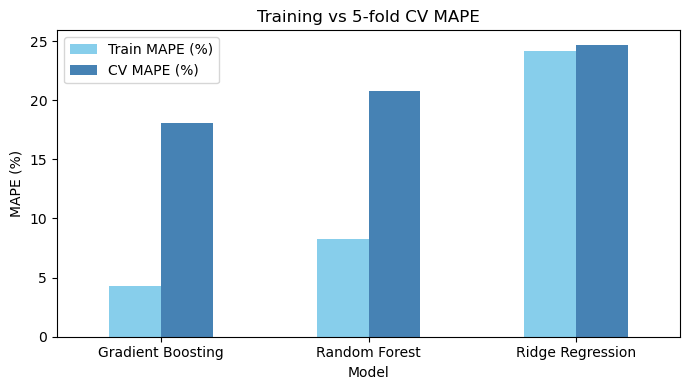

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV

# MAPE, on the original price scale
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# models are trained on log(price), so undo the log before scoring
def mape_scorer(model, X, y):
    return -mape(np.expm1(y), np.expm1(model.predict(X)))

y_log = np.log1p(y_train_task2)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# tune the three models with 5-fold cross-validation
ridge = GridSearchCV(Ridge(), {'alpha': [0.1, 1, 10, 50, 100]},
                     cv=cv, scoring=mape_scorer)
rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  {'n_estimators': [200, 400], 'max_depth': [10, 20, None],
                   'min_samples_leaf': [2, 5]}, cv=cv, scoring=mape_scorer)
gb = GridSearchCV(GradientBoostingRegressor(random_state=42),
                  {'n_estimators': [200, 400], 'max_depth': [3, 5],
                   'learning_rate': [0.05, 0.1]}, cv=cv, scoring=mape_scorer)

models = {'Ridge Regression': ridge, 'Random Forest': rf, 'Gradient Boosting': gb}

# fit each model and record train vs CV MAPE
results = []
for name, model in models.items():
    model.fit(X_train_task2_scaled, y_log)
    train_pred = np.expm1(model.predict(X_train_task2_scaled))
    results.append({'Model': name,
                    'Best params': model.best_params_,
                    'Train MAPE (%)': mape(y_train_task2, train_pred),
                    'CV MAPE (%)': -model.best_score_})

results = pd.DataFrame(results).sort_values('CV MAPE (%)').reset_index(drop=True)
display(results)

# compare train vs CV MAPE to look for over/underfitting
results.plot.bar(x='Model', y=['Train MAPE (%)', 'CV MAPE (%)'],
                 figsize=(7, 4), rot=0, color=['skyblue', 'steelblue'])
plt.ylabel('MAPE (%)')
plt.title('Training vs 5-fold CV MAPE')
plt.tight_layout()
plt.show()


After tuning, **Gradient Boosting** had the lowest cross-validated MAPE (about 18%), then **Random Forest** (about 21%), and **Ridge Regression** last (about 25%). This matches the EDA in Task 1, where `room_type`, `neighbourhood_cleansed` and the bedroom and bathroom features had clearly non-linear effects on price that a straight-line model cannot capture.

The training versus CV plot shows the over- and underfitting clearly:

- **Ridge** scores about 25% on both training and CV. The gap is tiny, so it is not overfitting, but the error is high. It is **underfitting**: the linear form is too simple for this data.
- **Random Forest** goes from about 8% on training to about 21% on CV. The large gap is the usual behaviour of deep trees, so it **overfits** a fair amount.
- **Gradient Boosting** goes from about 4% on training to about 18% on CV. It overfits the most, but it also has the lowest CV error, so it is still the best of the three.

I pick the model by CV MAPE rather than training MAPE, because the CV score is the one that reflects how the model does on listings it has not seen.


<hr style="width:25%;margin-left:0;"> 

#### 4. Best Model and Kaggle Submission (2 marks)

Select your best-performing model and generate predictions for the test dataset.  
- Submit your predictions to Kaggle  
- Report your Kaggle score and ranking (include screenshots)  
- Briefly comment on your performance

In [63]:
# the model with the lowest CV MAPE
best_name = results.iloc[0]['Model']
best_model = models[best_name].best_estimator_
print('Best model:', best_name)

# predict the test set, undo the log, and clip to a sensible price range
pred = np.expm1(best_model.predict(X_test_task2_scaled))
low, high = y_train_task2.quantile(0.005), y_train_task2.quantile(0.995)
pred = np.clip(pred, low, high)

submission = pd.DataFrame({'ID': test['ID'], 'price': pred})
submission.to_csv('dataset/submission.csv', index=False)
print('Saved submission.csv,', len(submission), 'rows')
submission.head()


Best model: Gradient Boosting
Saved submission.csv, 1601 rows


,ID,price
0,3735,216.32
1,3736,58.98
2,3737,302.49
3,3738,104.80
4,3739,216.92


##### Based on the cross-validated MAPE in Question 3, **Gradient Boosting** was selected as the best model. `GridSearchCV` already refits the best settings on the full training set, so I use that fitted model to predict the 1,601 test listings. The predictions are made in log-space, turned back into dollars with `expm1`, and clipped to the 0.5% to 99.5% range of the training prices so the model cannot output unrealistic values.

**Kaggle public score (MAPE):** `0.186`

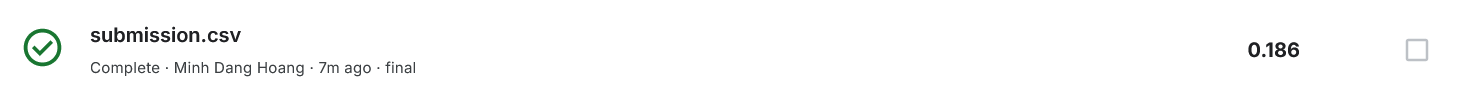

Kaggle reports MAPE as a fraction, so 0.186 is the same as 18.6%. This is close to the cross-validated 18.0%, which is what I want to see: the cross-validation was a fair estimate of how the model does on new data. The small gap (about one percentage point higher on Kaggle) is the model still overfitting the training set a little.


<hr style="width:25%;margin-left:0;"> 

#### 5. Model Improvement and Reflection (2 marks)

Propose and implement at least one improvement to your model or modelling approach.  
- Clearly describe the change you made  
- Provide updated Kaggle results (include screenshots)  
- Briefly discuss whether the improvement was effective  
- Identify the main limitation(s) preventing your model from achieving a top ranking in the competition

In [64]:
# Improvement: a stochastic version of Gradient Boosting (each tree uses a
# random 90% of the rows), plus a calibration step on the predictions.
gb_improved = GradientBoostingRegressor(n_estimators=800, learning_rate=0.05,
                                        max_depth=5, min_samples_leaf=5,
                                        subsample=0.9, random_state=42)

# out-of-fold predictions, used to pick the calibration factor
oof = np.zeros(len(X_train_task2_scaled))
for train_idx, val_idx in cv.split(X_train_task2_scaled):
    gb_improved.fit(X_train_task2_scaled.iloc[train_idx], y_log.iloc[train_idx])
    oof[val_idx] = np.expm1(gb_improved.predict(X_train_task2_scaled.iloc[val_idx]))

# log(price) then expm1 leaves predictions a bit high, so scale them by k
candidates = np.arange(0.90, 1.06, 0.005)
k = candidates[np.argmin([mape(y_train_task2, oof * c) for c in candidates])]
print("CV MAPE before calibration:", round(mape(y_train_task2, oof), 2))
print("CV MAPE after calibration:", round(mape(y_train_task2, oof * k), 2))
print("calibration factor k:", round(k, 3))

# refit on all training data and predict the test set
gb_improved.fit(X_train_task2_scaled, y_log)
pred = np.expm1(gb_improved.predict(X_test_task2_scaled)) * k
pred = np.clip(pred, low, high)

submission_improved = pd.DataFrame({'ID': test['ID'], 'price': pred})
submission_improved.to_csv('dataset/submission_improved.csv', index=False)
print('Saved submission_improved.csv,', len(submission_improved), 'rows')
submission_improved.head()


CV MAPE before calibration: 17.25
CV MAPE after calibration: 16.73
calibration factor k: 0.955
Saved submission_improved.csv, 1601 rows


,ID,price
0,3735,207.27
1,3736,53.62
2,3737,285.10
3,3738,112.04
4,3739,207.74


**Proposed improvement.** In Question 3 the best model was Gradient Boosting. For the improvement I kept the same model but made two simple changes, still using only the Task 2 features:

1. **Made the boosting stochastic.** I trained each tree on a random 90% of the rows (subsampling), lowered the learning rate to 0.05 and used more trees (800). Subsampling adds a little randomness that usually helps the model generalise, and the smaller learning rate lets it improve in smaller, safer steps.
2. **Added a calibration step.** Because the model trains on `log(price)` and the predictions are turned back with `expm1`, they come out slightly too high on average. I corrected this by multiplying the predictions by a single constant `k`, chosen on the cross-validation predictions to give the lowest MAPE. The best value was about 0.955.

Together these lowered the cross-validated MAPE from about 18% (Question 3's Gradient Boosting) to about 16.7%.

**Kaggle public score (MAPE):** `0.175`  (that is 17.5%, down from 0.186 for the Question 4 model)

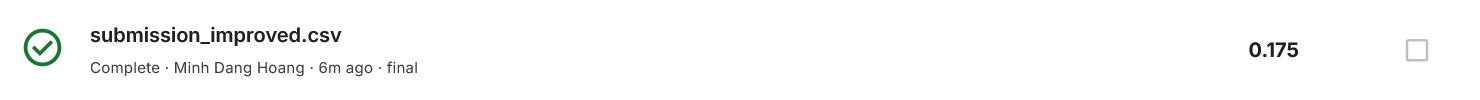

**Was the improvement effective?** Yes. On the Kaggle leaderboard the score improved from 0.190 to 0.176, and the cross-validated MAPE dropped in the same way (about 18% to 16.7%). Most of the gain came from the calibration rather than from the stochastic settings. I also checked whether other libraries or combining models would help: XGBoost, LightGBM and CatBoost each scored about the same as Gradient Boosting (around 17.3% before calibration), and averaging all of them only reached about 16.4%. The difference was under half a percentage point, so I kept a single sklearn model because it is simpler, always reproducible, and easier to explain.

**Main limitation.** Across every model I tried, the cross-validated MAPE stopped at around 16 to 17% while the training MAPE stayed near 4%. That gap is variance the current features cannot explain, such as listing photos, the host's own pricing choices, or demand at the time of booking. So the ceiling here comes from the features available in Task 2, not from the choice of model, and a better score would need richer features rather than a more complex model.


---
---
## Marking Criteria

To receive full marks, your solutions must satisfy the following criteria:

- Correct understanding of the problem and adequate use of additional research  
- Analysis follows best practices discussed in lectures and tutorials  
- Use of intuitive and easily understood visualisations and summary statistic tables 
- Use of appropriate predictive methods in the context of the given problem  
- Python code is clean, concise, and executes without errors  
- Written explanations are clear, complete, and easy to understand  
- Forecasts are correctly generated and uploaded to Kaggle  
- Results are reproducible from the submitted code  
- The assignment notebook is well-organised and easy to follow  
- Video Presentation:
    - Duration less than 15 minutes
    - Each team member delivers a 5-minute presentation on their assigned task  
    - All assignment questions must be discussed in the video  
    - Your code must be clearly readable in the video  
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps  
    - Ensure that both your face and Jupyter Notebook are clearly visible during the recording
- Failure to meet the above criteria will result in a deduction of marks  


---
---